In [1]:
import pandas as pd

df = pd.read_csv("netflix_movies&shows.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [2]:
print(df.shape)

(8807, 12)


In [3]:
print(df.dtypes)

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [4]:
movies = df[df["type"] == "Movie"]

print(movies[
    ["title", "type", "release_year", "rating"]
].head(10))

                                                title   type  release_year  \
0                                Dick Johnson Is Dead  Movie          2020   
6                    My Little Pony: A New Generation  Movie          2021   
7                                             Sankofa  Movie          1993   
9                                        The Starling  Movie          2021   
12                                       Je Suis Karl  Movie          2021   
13                   Confessions of an Invisible Girl  Movie          2021   
16  Europe's Most Dangerous Man: Otto Skorzeny in ...  Movie          2020   
18                                          Intrusion  Movie          2021   
22                                    Avvai Shanmughi  Movie          1996   
23       Go! Go! Cory Carson: Chrissy Takes the Wheel  Movie          2021   

   rating  
0   PG-13  
6      PG  
7   TV-MA  
9   PG-13  
12  TV-MA  
13  TV-PG  
16  TV-MA  
18  TV-14  
22  TV-PG  
23   TV-Y  


In [5]:
tv_shows = df[df["type"] == "TV Show"]

print(tv_shows[
    ["title", "type", "release_year", "rating"]
].head(10))

                                  title     type  release_year rating
1                         Blood & Water  TV Show          2021  TV-MA
2                             Ganglands  TV Show          2021  TV-MA
3                 Jailbirds New Orleans  TV Show          2021  TV-MA
4                          Kota Factory  TV Show          2021  TV-MA
5                         Midnight Mass  TV Show          2021  TV-MA
8         The Great British Baking Show  TV Show          2021  TV-14
10  Vendetta: Truth, Lies and The Mafia  TV Show          2021  TV-MA
11                     Bangkok Breaking  TV Show          2021  TV-MA
14      Crime Stories: India Detectives  TV Show          2021  TV-MA
15                    Dear White People  TV Show          2021  TV-MA


In [6]:
sorted_df = df.sort_values(
    by="release_year",
    ascending=False
)

print(sorted_df[
    ["title", "type", "release_year", "rating"]
].head(10))

                                              title     type  release_year  \
1                                     Blood & Water  TV Show          2021   
2                                         Ganglands  TV Show          2021   
3                             Jailbirds New Orleans  TV Show          2021   
31                               Chicago Party Aunt  TV Show          2021   
30                                  Ankahi Kahaniya    Movie          2021   
25                             Love on the Spectrum  TV Show          2021   
23     Go! Go! Cory Carson: Chrissy Takes the Wheel    Movie          2021   
20  Monsters Inside: The 24 Faces of Billy Milligan  TV Show          2021   
19                                           Jaguar  TV Show          2021   
18                                        Intrusion    Movie          2021   

   rating  
1   TV-MA  
2   TV-MA  
3   TV-MA  
31  TV-MA  
30  TV-14  
25  TV-14  
23   TV-Y  
20  TV-14  
19  TV-MA  
18  TV-14  


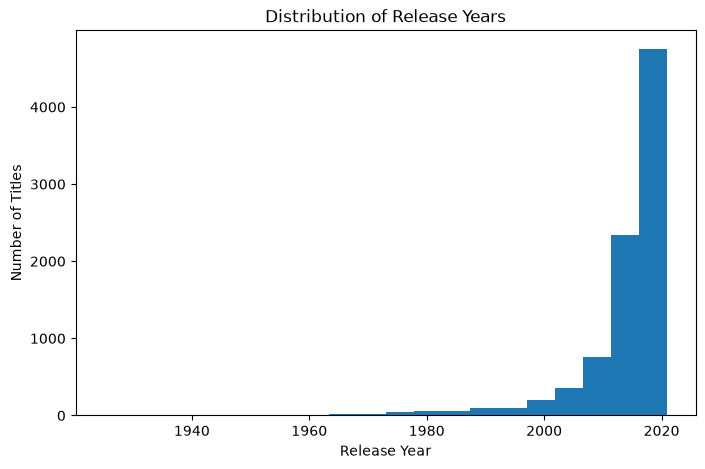

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["release_year"], bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [8]:
print("Mean =", df["release_year"].mean())
print("Median =", df["release_year"].median())
print("Mode =", df["release_year"].mode()[0])
print("Standard Deviation =", df["release_year"].std())

Mean = 2014.1801975701146
Median = 2017.0
Mode = 2018
Standard Deviation = 8.819312130833966


In [9]:
print(df["release_year"].describe())

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


In [10]:
type_avg = df.groupby(
    "type"
)["release_year"].mean()

print(type_avg)

type
Movie      2013.121514
TV Show    2016.605755
Name: release_year, dtype: float64


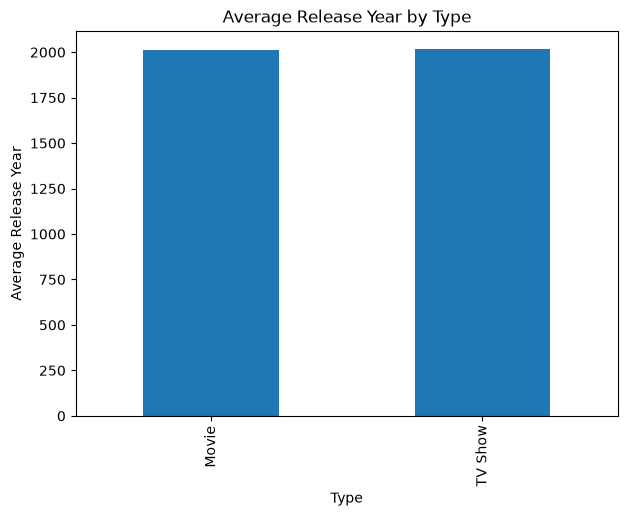

In [11]:
type_avg.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Average Release Year by Type")
plt.xlabel("Type")
plt.ylabel("Average Release Year")

plt.show()

In [12]:
df["duration_num"] = df["duration"].str.extract(
    r"(\d+)"
).astype(float)

corr = df[
    ["release_year", "duration_num"]
].corr()

print(corr)

              release_year  duration_num
release_year      1.000000     -0.249182
duration_num     -0.249182      1.000000
